PINN Modeling

In [1]:
# Import shared surface-potential model
import torch
import matplotlib.pyplot as plt

from physics_loss import physics_loss
from phis_init import phi_init

from SurfacePotential import (
    DeltaPhisPINN,
    predict_phis,
)

Training Parts: 
1. Input definiton
2. Training Framework

In [2]:
# Define parameters, training points and model
# Use CPU for stable PINN training
device = "cpu"

dtype = torch.float32

torch.manual_seed(42)
dtype = torch.float32

torch.manual_seed(42)


# Physical parameters
T = 300.0
NA = 1.0e16

eps_sic = (
    9.26
    * 8.854e-14
)

Cox = 7.0e-8

Vfbs0 = -1.0

Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1

Eg = 3.26

Ec_minus_Ei = (
    Eg / 2.0
)

Qox = 1.602e-7


# PINN domain
VGS_MIN = -10.0
VGS_MAX = 30.0

PHIF_MIN = 0.0
PHIF_MAX = 15.0


# Random collocation points
N_RANDOM = 6000

Vgs_random = (
    VGS_MIN
    + (
        VGS_MAX
        - VGS_MIN
    )
    * torch.rand(
        N_RANDOM,
        1,
        dtype=dtype,
        device=device,
    )
)

phi_f_random = (
    PHIF_MIN
    + (
        PHIF_MAX
        - PHIF_MIN
    )
    * torch.rand(
        N_RANDOM,
        1,
        dtype=dtype,
        device=device,
    )
)


# Dense points in the I-V operating region
Vgs_dense_axis = torch.linspace(
    0.0,
    20.0,
    81,
    dtype=dtype,
    device=device,
)

phi_f_dense_axis = torch.linspace(
    0.0,
    15.0,
    61,
    dtype=dtype,
    device=device,
)

Vgs_dense_grid, phi_f_dense_grid = torch.meshgrid(
    Vgs_dense_axis,
    phi_f_dense_axis,
    indexing="ij",
)

Vgs_dense = (
    Vgs_dense_grid.reshape(-1, 1)
)

phi_f_dense = (
    phi_f_dense_grid.reshape(-1, 1)
)


# Extra collocation points around the previous unstable region
Vgs_focus_axis = torch.linspace(
    10.0,
    18.0,
    65,
    dtype=dtype,
    device=device,
)

phi_f_focus_axis = torch.linspace(
    0.0,
    15.0,
    41,
    dtype=dtype,
    device=device,
)

Vgs_focus_grid, phi_f_focus_grid = torch.meshgrid(
    Vgs_focus_axis,
    phi_f_focus_axis,
    indexing="ij",
)

Vgs_focus = (
    Vgs_focus_grid.reshape(-1, 1)
)

phi_f_focus = (
    phi_f_focus_grid.reshape(-1, 1)
)


# Combine collocation points
Vgs_train = torch.cat(
    [
        Vgs_random,
        Vgs_dense,
        Vgs_focus,
    ],
    dim=0,
)

phi_f_train = torch.cat(
    [
        phi_f_random,
        phi_f_dense,
        phi_f_focus,
    ],
    dim=0,
)

N_train = (
    Vgs_train.shape[0]
)


# Shuffle training points
shuffle_idx = torch.randperm(
    N_train,
    device=device,
)

Vgs_train = (
    Vgs_train[shuffle_idx]
)

phi_f_train = (
    phi_f_train[shuffle_idx]
)


# Create shared PINN model
Model = DeltaPhisPINN().to(
    device=device,
    dtype=dtype,
)


MODEL_PATH = (
    "phis_PINN_surface.pth"
)


print(
    "device =",
    device
)

print(
    "Training points =",
    N_train
)

print(
    "Vgs range =",
    Vgs_train.min().item(),
    "to",
    Vgs_train.max().item(),
    "V"
)

print(
    "phi_f range =",
    phi_f_train.min().item(),
    "to",
    phi_f_train.max().item(),
    "V"
)

device = cpu
Training points = 13606
Vgs range = -9.958761215209961 to 29.992176055908203 V
phi_f range = 0.0 to 15.0 V


PINN Training

Epoch     0/4000, L_SPE = 2.957058e+02
Epoch   100/4000, L_SPE = 1.613820e+01
Epoch   200/4000, L_SPE = 1.080860e+01
Epoch   300/4000, L_SPE = 7.377280e+00
Epoch   400/4000, L_SPE = 5.199405e+00
Epoch   500/4000, L_SPE = 3.908623e+00
Epoch   600/4000, L_SPE = 3.200429e+00
Epoch   700/4000, L_SPE = 2.778220e+00
Epoch   800/4000, L_SPE = 2.499460e+00
Epoch   900/4000, L_SPE = 2.280408e+00
Epoch  1000/4000, L_SPE = 2.205562e+00
Epoch  1100/4000, L_SPE = 2.161657e+00
Epoch  1200/4000, L_SPE = 2.132258e+00
Epoch  1300/4000, L_SPE = 2.097947e+00
Epoch  1400/4000, L_SPE = 2.065477e+00
Epoch  1500/4000, L_SPE = 2.032537e+00
Epoch  1600/4000, L_SPE = 1.997090e+00
Epoch  1700/4000, L_SPE = 1.973951e+00
Epoch  1800/4000, L_SPE = 1.936152e+00
Epoch  1900/4000, L_SPE = 1.905559e+00
Epoch  2000/4000, L_SPE = 1.878521e+00
Epoch  2100/4000, L_SPE = 1.852780e+00
Epoch  2200/4000, L_SPE = 1.827146e+00
Epoch  2300/4000, L_SPE = 1.790702e+00
Epoch  2400/4000, L_SPE = 1.755638e+00
Epoch  2500/4000, L_SPE =

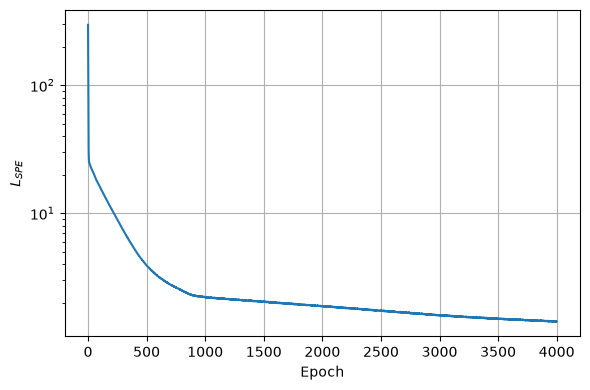

In [3]:
# Train surface-potential PINN
EPOCHS = 4000

BATCH_SIZE = 512

LEARNING_RATE = 5.0e-5


optimizer = torch.optim.Adam(
    Model.parameters(),
    lr=LEARNING_RATE,
    foreach=False,
)

loss_history = []

best_loss = float(
    "inf"
)


Model.train()


for ep in range(
    EPOCHS
):

    permutation = torch.randperm(
        N_train,
        device=device,
    )

    epoch_loss = 0.0

    batch_count = 0


    for start in range(
        0,
        N_train,
        BATCH_SIZE,
    ):

        idx = permutation[
            start:
            start + BATCH_SIZE
        ]


        Vgs_batch = (
            Vgs_train[idx]
        )

        phi_f_batch = (
            phi_f_train[idx]
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        phis_init_batch = phi_init(
            Vgs_batch,
            phi_f_batch,
            T,
            NA,
            eps_sic,
            Cox,
            Vfbs0,
            Dit_mid,
            Dit_edge,
            sigma_it,
            Eg,
        ).reshape(-1, 1)


        delta_phis = Model(
            Vgs_batch,
            phi_f_batch,
        )


        phis_PINN = (
            phis_init_batch
            + delta_phis
        )


        loss = physics_loss(
            phis_PINN,
            Vgs_batch,
            phi_f_batch,
            T,
            NA,
            eps_sic,
            Cox,
            Vfbs0,
            Qox,
            Dit_mid,
            Dit_edge,
            sigma_it,
            Ec_minus_Ei,
            Eg,
        )


        if not torch.isfinite(
            loss
        ):
            raise RuntimeError(
                f"Non-finite loss at epoch {ep}"
            )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            Model.parameters(),
            max_norm=10.0,
        )


        optimizer.step()


        epoch_loss += (
            loss.item()
        )

        batch_count += 1


    epoch_loss /= (
        batch_count
    )


    loss_history.append(
        epoch_loss
    )


    if (
        epoch_loss
        < best_loss
    ):

        best_loss = (
            epoch_loss
        )

        torch.save(
            Model.state_dict(),
            MODEL_PATH,
        )


    if (
        ep % 100 == 0
        or ep == EPOCHS - 1
    ):

        print(
            f"Epoch {ep:5d}/{EPOCHS}, "
            f"L_SPE = {epoch_loss:.6e}"
        )


# Reload best model
state_dict = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

Model.load_state_dict(
    state_dict,
    strict=True,
)

Model.eval()


print(
    "Best loss =",
    best_loss
)

print(
    "Saved to:",
    MODEL_PATH
)


plt.figure(
    figsize=(6, 4)
)

plt.plot(
    loss_history
)

plt.yscale(
    "log"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    r"$L_{SPE}$"
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()

Curve Plotting

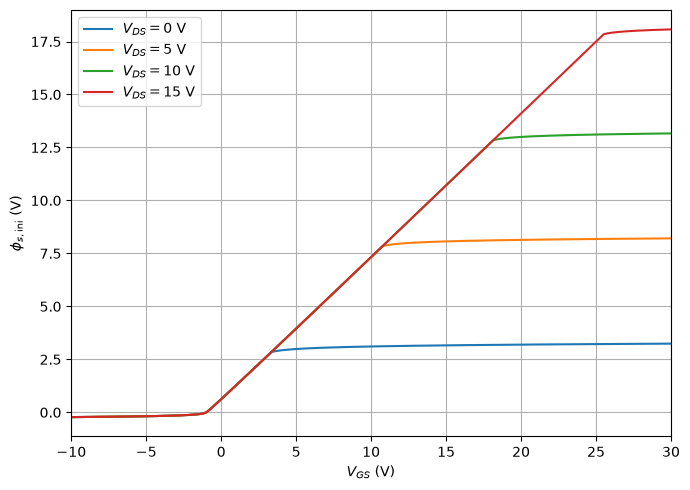

In [4]:
# Check analytical initial guess before PINN training
Vgs_test = torch.linspace(
    -10.0,
    30.0,
    500,
    dtype=dtype,
    device=device,
).reshape(-1, 1)

plt.figure(figsize=(7, 5))

for VDS_VALUE in [0.0, 5.0, 10.0, 15.0]:

    Vds_test = torch.full_like(
        Vgs_test,
        VDS_VALUE
    )

    phis_ini_test = phi_init(
        Vgs_test,
        Vds_test,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Eg,
    )

    plt.plot(
        Vgs_test.cpu().numpy(),
        phis_ini_test.cpu().numpy(),
        label=rf"$V_{{DS}}={VDS_VALUE:.0f}$ V"
    )

plt.xlabel(r"$V_{GS}$ (V)")
plt.ylabel(r"$\phi_{s,\mathrm{ini}}$ (V)")
plt.xlim(-10, 30)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

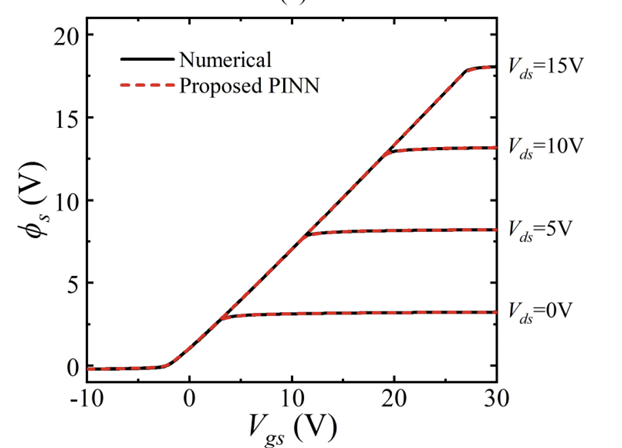